In [1]:
# imports
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import requests
import ssl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# EDA 
Target variable is "Total Interactions". 

In [2]:
# !pip install ucimlrepo
def load_data(uci_id:int):
    try:
        ssl._create_default_https_context = ssl._create_unverified_context
        data = fetch_ucirepo(id=uci_id)
    except requests.exceptions.ConnectionError:
         print("Error connecting to server. Please check your internet connection and try again.") 

    return data

In [3]:
facebook_metrics = load_data(368)
X = facebook_metrics.data.features 
y = facebook_metrics.data.targets 
  
print(facebook_metrics.metadata) 
print(facebook_metrics.variables)

{'uci_id': 368, 'name': 'Facebook Metrics', 'repository_url': 'https://archive.ics.uci.edu/dataset/368/facebook+metrics', 'data_url': 'https://archive.ics.uci.edu/static/public/368/data.csv', 'abstract': "Facebook performance metrics of a renowned cosmetic's brand Facebook page.", 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 500, 'num_features': 18, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Total Interactions'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2016, 'last_updated': 'Wed Mar 20 2024', 'dataset_doi': '10.24432/C5QK55', 'creators': ['Srgio Moro', 'Paulo Rita', 'Bernardo Vala'], 'intro_paper': {'title': 'Predicting social media performance metrics and evaluation of the impact on brand building: A data mining approach', 'authors': 'Sérgio Moro, P. Rita, Bernardo Vala', 'published_in': 'Journal of Business Research', 'year': 2016, 'url': 'htt

In [4]:
any_missing = X.isnull().values.any()
print(f"Missing values > ")

missing_count = X.isnull().sum()
print("Number of missing values in each column:")
print(missing_count)


# X = X.dropna()

Missing values > 
Number of missing values in each column:
Page total likes                                                       0
Type                                                                   0
Category                                                               0
Post Month                                                             0
Post Weekday                                                           0
Post Hour                                                              0
Paid                                                                   1
Lifetime Post Total Reach                                              0
Lifetime Post Total Impressions                                        0
Lifetime Engaged Users                                                 0
Lifetime Post Consumers                                                0
Lifetime Post Consumptions                                             0
Lifetime Post Impressions by people who have liked your Page     

Dropping 5 observations, because of missing values.

In [5]:
X.describe()

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.00000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.00000,499.000000,496.000000
mean,123194.176000,1.880000,7.038000,4.150000,7.840000,0.278557,13903.36000,2.958595e+04,920.344000,798.772000,1415.130000,1.676638e+04,6585.488000,609.986000,7.48200,177.945892,27.266129
std,16272.813214,0.852675,3.307936,2.030701,4.368589,0.448739,22740.78789,7.680325e+04,985.016636,882.505013,2000.594118,5.979102e+04,7682.009405,612.725618,21.18091,323.398742,42.613292
min,81370.000000,1.000000,1.000000,1.000000,1.000000,0.000000,238.00000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.00000,0.000000,0.000000
25%,112676.000000,1.000000,4.000000,2.000000,3.000000,0.000000,3315.00000,5.694750e+03,393.750000,332.500000,509.250000,3.969750e+03,2181.500000,291.000000,1.00000,56.500000,10.000000
50%,129600.000000,2.000000,7.000000,4.000000,9.000000,0.000000,5281.00000,9.051000e+03,625.500000,551.500000,851.000000,6.255500e+03,3417.000000,412.000000,3.00000,101.000000,19.000000
75%,136393.000000,3.000000,10.000000,6.000000,11.000000,1.000000,13168.00000,2.208550e+04,1062.000000,955.500000,1463.000000,1.486050e+04,7989.000000,656.250000,7.00000,187.500000,32.250000
max,139441.000000,3.000000,12.000000,7.000000,23.000000,1.000000,180480.00000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.00000,5172.000000,790.000000


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

type is categorical
paid is float64 (0 or 1)
like is float
share is float

In [7]:
print(X['Type'])
print(X['Type'].unique())
category_percentages = X['Type'].value_counts(normalize=True) * 100
print(category_percentages)

0       Photo
1      Status
2       Photo
3       Photo
4       Photo
        ...  
495     Photo
496     Photo
497     Photo
498     Photo
499     Photo
Name: Type, Length: 500, dtype: object
['Photo' 'Status' 'Link' 'Video']
Type
Photo     85.2
Status     9.0
Link       4.4
Video      1.4
Name: proportion, dtype: float64


In [8]:
X.head()

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0


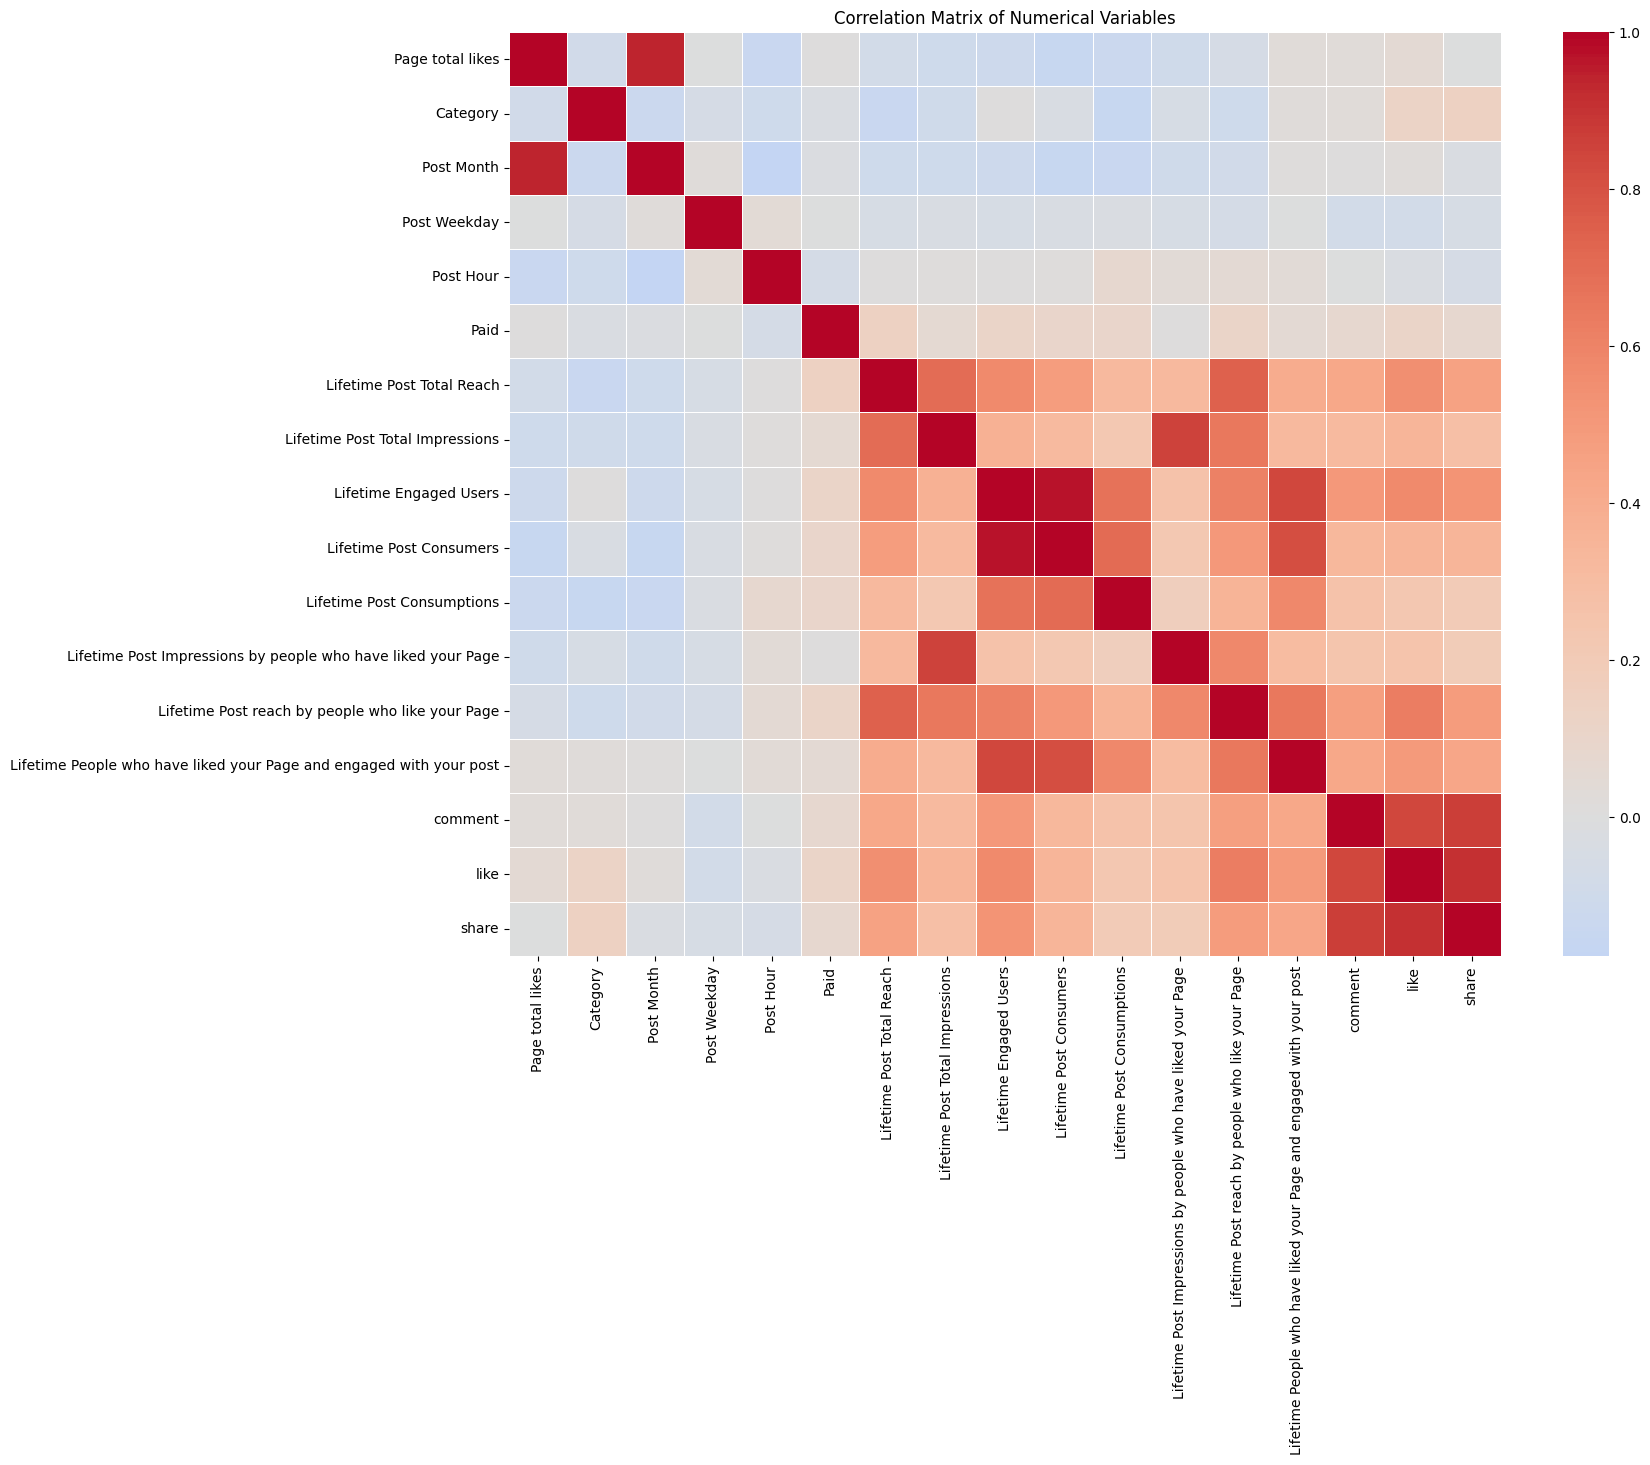

In [9]:
# Select only numeric columns for the correlation matrix
numeric_cols = X.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=0.5, center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [10]:
import pandas as pd

def apply_custom_transformations(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    data['Paid'] = data['Paid'].fillna(data['Paid'].mean())#.astype(int)
    data['like'] = data['like'].fillna(data['like'].mean())#.astype(int)
    data['share'] = data['share'].fillna(data['share'].mean())#.astype(int)

    data = pd.get_dummies(data, columns=['Type'], prefix='', prefix_sep='').astype(int)

    data.drop(['Post Month', 'Lifetime Post Consumptions'], axis=1, inplace=True)

    return data

X_transformed = apply_custom_transformations(X)

print(X_transformed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype
---  ------                                                               --------------  -----
 0   Page total likes                                                     500 non-null    int64
 1   Category                                                             500 non-null    int64
 2   Post Weekday                                                         500 non-null    int64
 3   Post Hour                                                            500 non-null    int64
 4   Paid                                                                 500 non-null    int64
 5   Lifetime Post Total Reach                                            500 non-null    int64
 6   Lifetime Post Total Impressions                                      500 non-null    int64
 7   Lifetime Engaged Users    

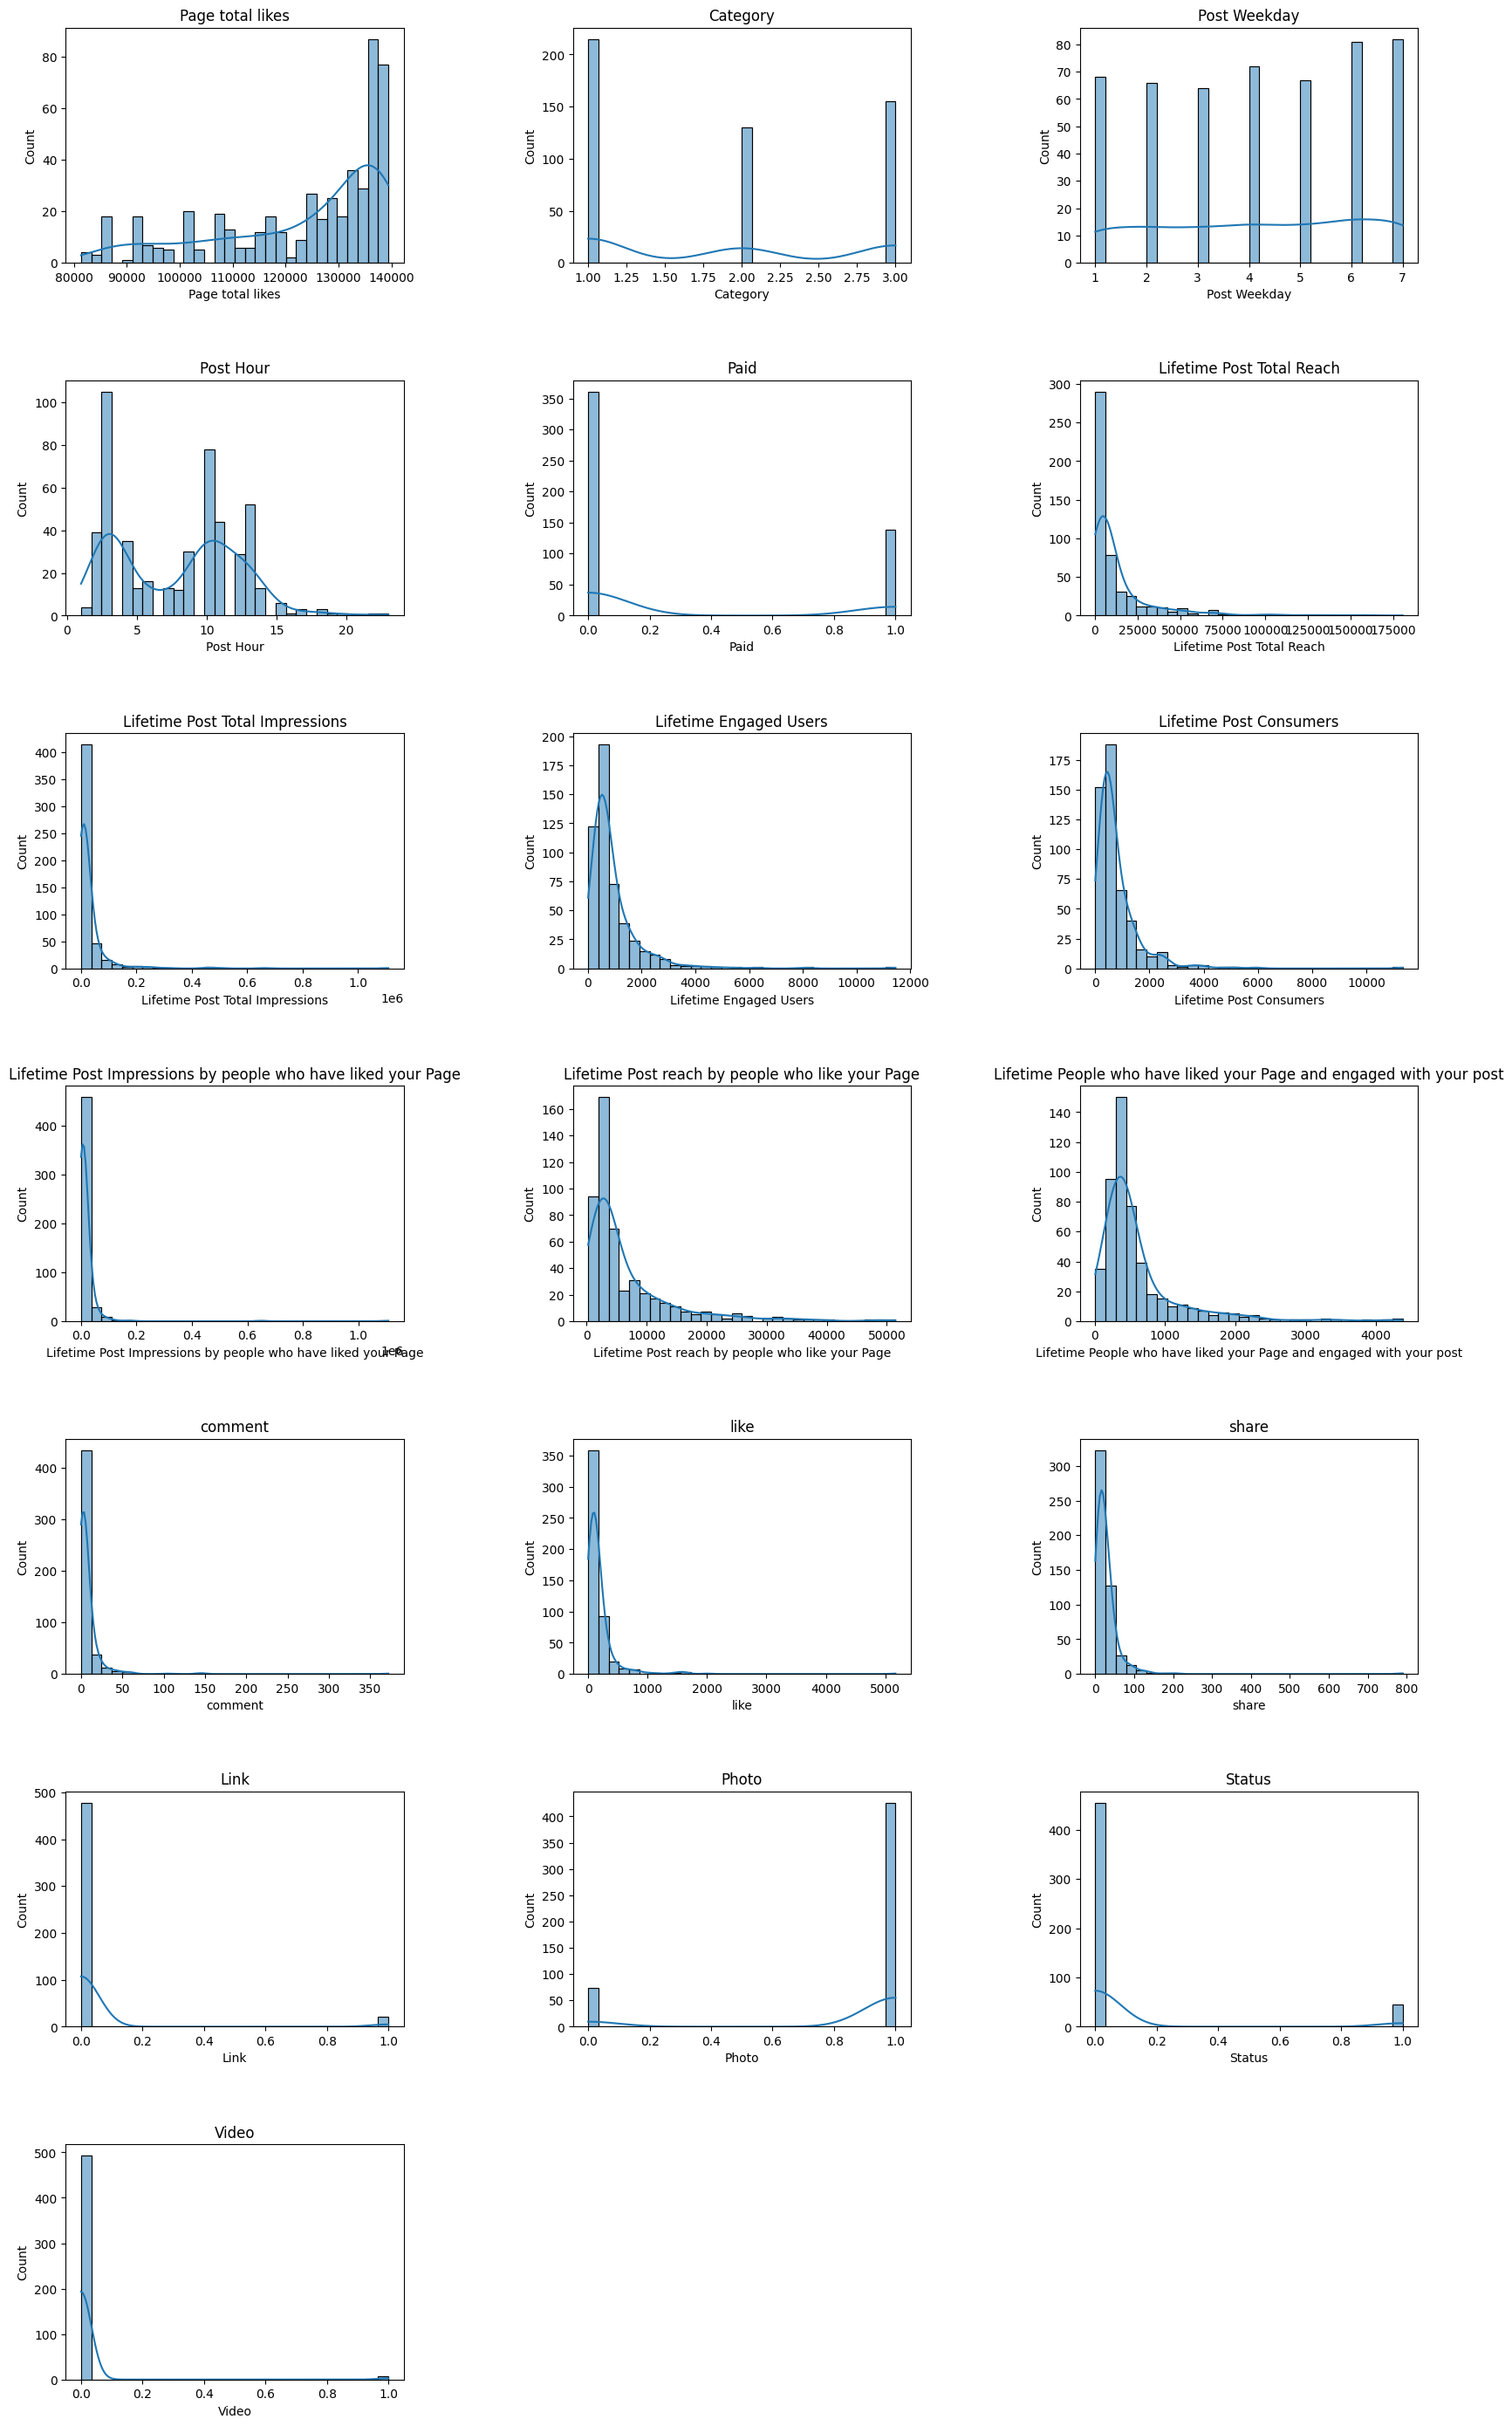

In [12]:
def distributions(df):
    num_columns = df.shape[1]
    rows = (num_columns + 2) // 3  

    plt.figure(figsize=(20, 5 * rows)) 
    plt.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, column in enumerate(df.columns):
        plt.subplot(rows, 3, i + 1)
        if df[column].dtype == 'bool':
            sns.countplot(x=df[column])
        else:
            sns.histplot(df[column], bins=30, kde=True)  
        plt.title(column)

    plt.show()

df = X_transformed
distributions(df)

In [13]:
def preprocess_features(data):
    transformed_data = data.copy()
    features_to_scale = ['Page total likes', 'Lifetime Post Total Reach', 'Lifetime Post Total Impressions',
    'Lifetime Engaged Users', 'Lifetime Post Consumers', 'comment', 'like', 'share']


    for feature in features_to_scale:
        transformed_data[feature] = np.log1p(transformed_data[feature])

    scaler = StandardScaler()
    transformed_data[features_to_scale] = scaler.fit_transform(transformed_data[features_to_scale])

    return transformed_data
X_scaled = X_transformed  

preprocessed_data = preprocess_features(X_scaled)

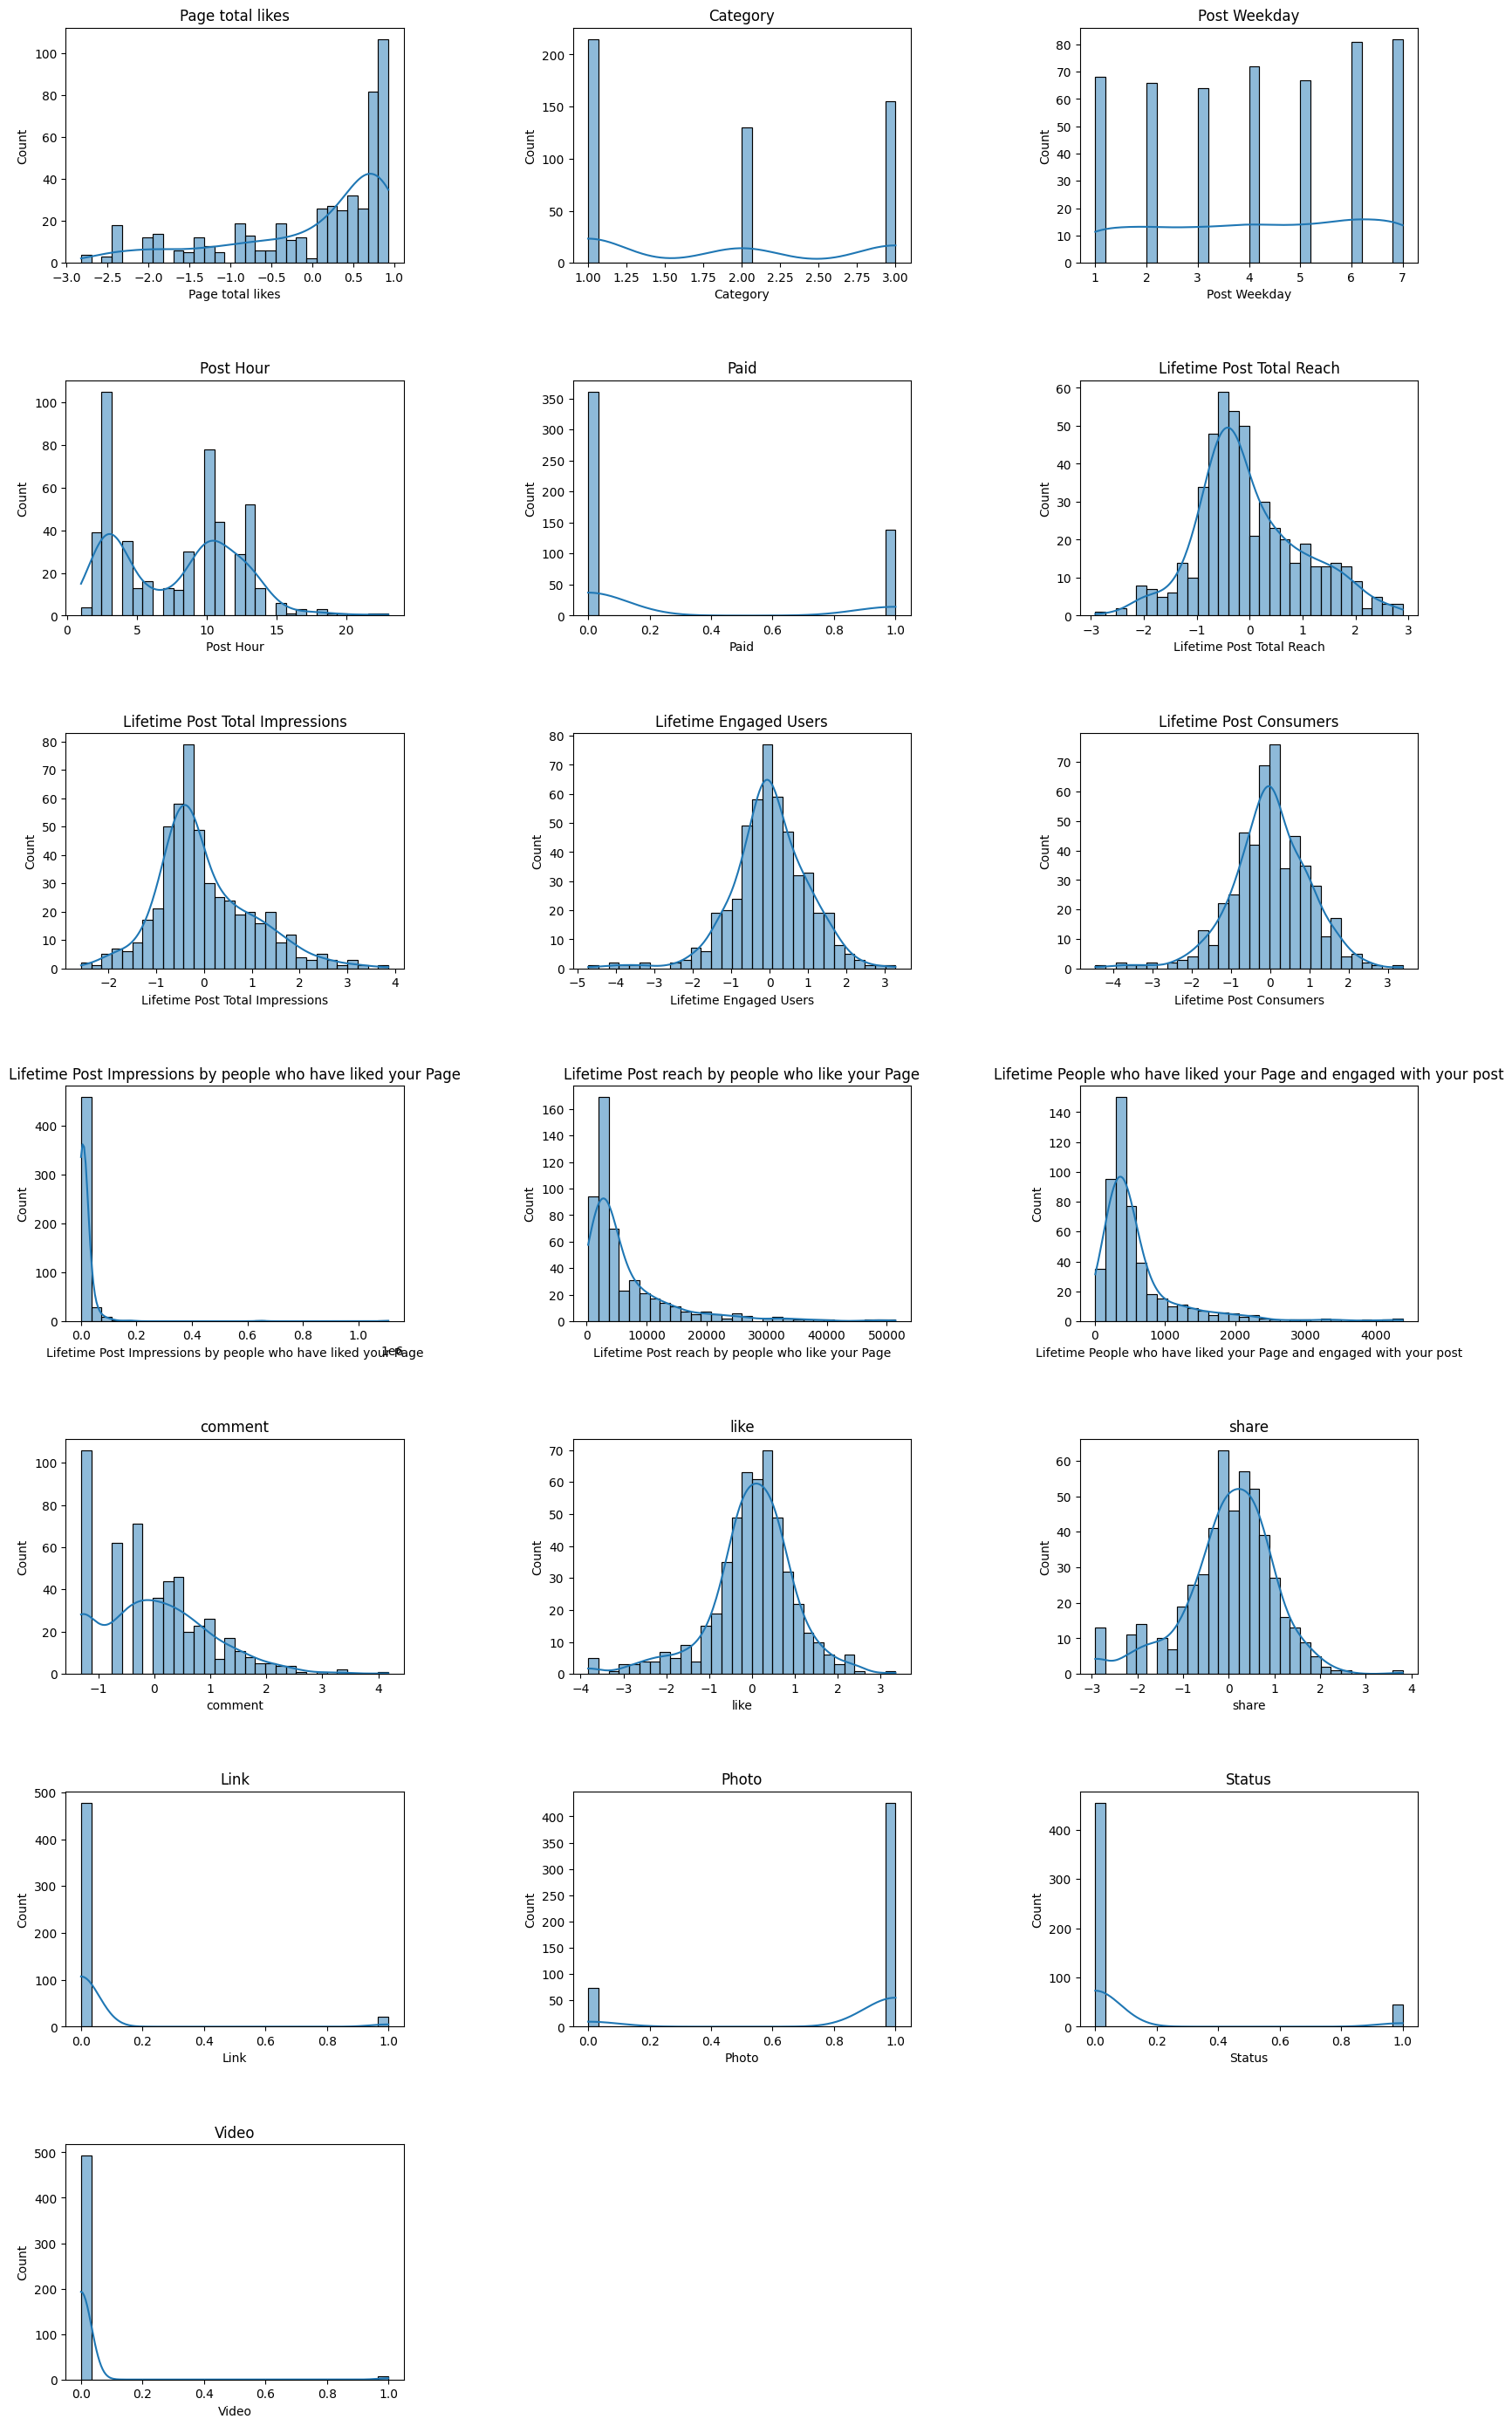

In [14]:
df = preprocessed_data
distributions(df)

# Data Preprocessing

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=999)

In [16]:
y_train.isna().sum(), y_test.isna().sum()

(Total Interactions    0
 dtype: int64,
 Total Interactions    0
 dtype: int64)

In [17]:
from sklearn.preprocessing import StandardScaler

def mean_imputation(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data['Paid'] = data['Paid'].fillna(data['Paid'].mean())#.astype(int)
    data['like'] = data['like'].fillna(data['like'].mean())#.astype(int)
    data['share'] = data['share'].fillna(data['share'].mean())#.astype(int)
    return data

def onehot(df):
    data = df.copy()
    data = pd.get_dummies(data, columns=['Type'], prefix='', prefix_sep='').astype(int)
    data.drop(['Post Month', 'Lifetime Post Consumptions'], axis=1, inplace=True)
    return data


def preprocess_pipeline(train_test=(X_train, X_test, y_train, y_test)):
    X_train, X_test, y_train, y_test = train_test
    X_train = onehot(mean_imputation(X_train))
    X_test = onehot(mean_imputation(X_test))
    
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_Y.fit_transform(y_train)
    y_test_scaled = scaler_Y.transform(y_test)
    data = (X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled)
    scalers = (scaler_X, scaler_Y)
    return data, scalers

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 18)
(100, 18)
(400, 1)
(100, 1)


In [19]:
data, scalers = preprocess_pipeline(train_test=(X_train, X_test, y_train, y_test))

X_train_p, X_test_p, y_train_p, y_test_p = data

The dataset contains 18 features and 500 observations, target variable is "Total interactions".

In [20]:
from KNeighbors import KNNRegression

knn = KNNRegression()
knn.fit(X_train_p, y_train_p)
y_pred = knn.predict(X_test_p)


In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'Mean Squared Error      : {mse:^10.2f}')
    print(f'Root Mean Squared Error : {rmse:^10.2f}')
    print(f'Mean Absolute Error     : {mae:^10.2f}')
    print(f'R^2 Score               : {r2:^10.2f}')

# KNN: variable *k* and distance function

In [22]:
from KNeighbors import KNNRegression
from sklearn.neighbors import KNeighborsRegressor
import time


times_knn = []
times_knn_sklearn = []

for k in range(1, 11):
    print(f'k = {k}')

    # KNNRegression
    start_time = time.time()
    knn = KNNRegression(k_neighbors=k, dist_func='manhattan')
    knn.fit(X_train_p, y_train_p)
    y_pred = knn.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_knn.append(elapsed_time)
    print(f"KNNRegression time elapsed      \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred)
    print()

    # KNeighborsRegressor from sklearn
    start_time = time.time()
    knn_sklearn = KNeighborsRegressor(n_neighbors=k, weights='distance', p=1, algorithm='brute') 
    knn_sklearn.fit(X_train_p, y_train_p)
    y_pred_sklearn = knn_sklearn.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_knn_sklearn.append(elapsed_time)
    print(f"KNeighborsRegressor time elapsed \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred_sklearn)
    print("-" * 50)


print(f"Avg time for KNNRegression:      \t {np.mean(times_knn):.2f} ± {np.std(times_knn):.2f}")
print(f"Avg time for KNeighborsRegressor:\t {np.mean(times_knn_sklearn):.2f} ± {np.std(times_knn_sklearn):.2f}")

k = 1
KNNRegression time elapsed      	0.12
Mean Squared Error      :    0.10   
Root Mean Squared Error :    0.32   
Mean Absolute Error     :    0.19   
R^2 Score               :    0.76   

KNeighborsRegressor time elapsed 	0.28
Mean Squared Error      :    0.10   
Root Mean Squared Error :    0.32   
Mean Absolute Error     :    0.19   
R^2 Score               :    0.76   
--------------------------------------------------
k = 2
KNNRegression time elapsed      	0.12
Mean Squared Error      :    0.05   
Root Mean Squared Error :    0.22   
Mean Absolute Error     :    0.15   
R^2 Score               :    0.89   

KNeighborsRegressor time elapsed 	0.00
Mean Squared Error      :    0.05   
Root Mean Squared Error :    0.22   
Mean Absolute Error     :    0.15   
R^2 Score               :    0.89   
--------------------------------------------------
k = 3
KNNRegression time elapsed      	0.12
Mean Squared Error      :    0.05   
Root Mean Squared Error :    0.23   
Mean Absolute Error 

In [23]:
times_knn = []
times_knn_sklearn = []

for k in range(1, 11):
    print(f'k = {k}')

    # KNNRegression
    start_time = time.time()
    knn = KNNRegression(k_neighbors=k, dist_func='euclidean')
    knn.fit(X_train_p, y_train_p)
    y_pred = knn.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_knn.append(elapsed_time)
    print(f"KNNRegression time elapsed      \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred)
    print()

    # KNeighborsRegressor from sklearn
    start_time = time.time()
    knn_sklearn = KNeighborsRegressor(n_neighbors=k, weights='distance', p=2, algorithm='brute') 
    knn_sklearn.fit(X_train_p, y_train_p)
    y_pred_sklearn = knn_sklearn.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_knn_sklearn.append(elapsed_time)
    print(f"KNeighborsRegressor time elapsed \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred_sklearn)
    print("-" * 50)


print(f"Avg time for KNNRegression:      \t {np.mean(times_knn):.2f} ± {np.std(times_knn):.2f}")
print(f"Avg time for KNeighborsRegressor:\t {np.mean(times_knn_sklearn):.2f} ± {np.std(times_knn_sklearn):.2f}")

k = 1
KNNRegression time elapsed      	0.15
Mean Squared Error      :    0.09   
Root Mean Squared Error :    0.30   
Mean Absolute Error     :    0.20   
R^2 Score               :    0.78   

KNeighborsRegressor time elapsed 	0.00
Mean Squared Error      :    0.09   
Root Mean Squared Error :    0.30   
Mean Absolute Error     :    0.20   
R^2 Score               :    0.78   
--------------------------------------------------
k = 2
KNNRegression time elapsed      	0.14
Mean Squared Error      :    0.06   
Root Mean Squared Error :    0.25   
Mean Absolute Error     :    0.18   
R^2 Score               :    0.85   

KNeighborsRegressor time elapsed 	0.00
Mean Squared Error      :    0.06   
Root Mean Squared Error :    0.25   
Mean Absolute Error     :    0.18   
R^2 Score               :    0.85   
--------------------------------------------------
k = 3
KNNRegression time elapsed      	0.14
Mean Squared Error      :    0.06   
Root Mean Squared Error :    0.25   
Mean Absolute Error 

# LR: variable learning rate $\eta$

In [24]:
from sklearn.linear_model import LinearRegression
from LinearRegression import LinearRegression as LR 

times_lr = []
times_lr_sklearn = []
etas = [0.0001, 0.001, 0.01, 0.1, 0.3]
for e in etas:
    print(f'eta = {e}')
    start_time = time.time()
    lr = LR(epochs=10_000, eta=e)
    lr.fit(X_train_p, y_train_p.ravel())
    y_pred = lr.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_lr.append(elapsed_time)
    print("Own Linear Regression:")
    print(f"Own Linear Regression time elapsed\t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred)
    print()

print('*' * 50)
lr_sklearn = LinearRegression()
start_time = time.time()
lr_sklearn.fit(X_train_p, y_train_p)
y_pred_sklearn = lr_sklearn.predict(X_test_p)
end_time = time.time()
elapsed_time = end_time - start_time    
times_lr_sklearn.append(elapsed_time)
print("Linear Regression from sklearn:")
print(f"sklean Linear Regression time elapsed\t%.2f" %elapsed_time)
evaluate_model(y_test_p, y_pred_sklearn)
print("-" * 50)


print(f"Avg time for own LinearRegression:      \t {np.mean(times_lr):.2f} ± {np.std(times_lr):.2f}")
print(f"Avg time for sklearn LinearRegression:  \t {np.mean(times_lr_sklearn):.2f} ± {np.std(times_lr_sklearn):.2f}")

eta = 0.0001
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.04   
Root Mean Squared Error :    0.19   
Mean Absolute Error     :    0.11   
R^2 Score               :    0.91   

eta = 0.001
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.01   
Root Mean Squared Error :    0.08   
Mean Absolute Error     :    0.05   
R^2 Score               :    0.98   

eta = 0.01
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.00   
Root Mean Squared Error :    0.01   
Mean Absolute Error     :    0.00   
R^2 Score               :    1.00   

eta = 0.1
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.00   
Root Mean Squared Error :    0.01   
Mean Absolute Error     :    0.00   
R^2 Score               :    1.00   

eta = 0.3
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.00

## Compare with SGDRegressor from sklearn

In [46]:
from sklearn.linear_model import SGDRegressor
from LinearRegression import LinearRegression as LR

times_lr = []
times_sgd = []

etas = [0.0001, 0.001, 0.01, 0.1, 0.3]
for e in etas:  
    print(f'eta = {e}')
    start_time = time.time()
    lr = LR(epochs=10_000, eta=e)
    lr.fit(X_train_p, y_train_p.ravel())
    y_pred = lr.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_lr.append(elapsed_time)
    print("Own Linear Regression:")
    print(f"Own Linear Regression time elapsed\t%.2f" %elapsed_time)
    try:
        evaluate_model(y_test_p, y_pred)
    except Exception as ex:
        print(f"Failed with eta={e} due to the following error:\n{ex}")
    print()

    print('*' * 50)

    sgd = SGDRegressor(learning_rate='constant',  eta0=e, max_iter=1000, tol=1e-3)# learning_rate='constant': eta = eta0 ... eta0 is for intercept
    start_time = time.time()
    sgd.fit(X_train_p, y_train_p.ravel())
    y_pred_sgd = sgd.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time    
    times_sgd.append(elapsed_time)
    print("SGDRegressor:")
    print(f"SGDRegressor time elapsed   \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred_sgd)
    print("-" * 50)

print(f"Avg time for own LinearRegression:      \t {np.mean(times_lr):.2f} ± {np.std(times_lr):.2f}")
print(f"Avg time for SGDRegressor:  \t {np.mean(times_sgd):.2f} ± {np.std(times_sgd):.2f}")

eta = 0.0001
Own Linear Regression:
Own Linear Regression time elapsed	0.13
Mean Squared Error      :    0.04   
Root Mean Squared Error :    0.19   
Mean Absolute Error     :    0.11   
R^2 Score               :    0.91   

**************************************************
SGDRegressor:
SGDRegressor time elapsed   	0.00
Mean Squared Error      :    0.03   
Root Mean Squared Error :    0.18   
Mean Absolute Error     :    0.11   
R^2 Score               :    0.92   
--------------------------------------------------
eta = 0.001
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.01   
Root Mean Squared Error :    0.08   
Mean Absolute Error     :    0.05   
R^2 Score               :    0.98   

**************************************************
SGDRegressor:
SGDRegressor time elapsed   	0.00
Mean Squared Error      :    0.02   
Root Mean Squared Error :    0.13   
Mean Absolute Error     :    0.08   
R^2 Score               :    0.96   
------

## Compare with TensorFlow GD

In [44]:
from LinearRegression import LinearRegression as LR 
import tensorflow as tf

times_lr = []
times_lr_tf = []

m_cols = X_train_p.shape[1]
linear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(m_cols,))
])
batch_size = len(X_train_p)  # using batch size equal to the whole dataset for normal gradient descent

etas = [0.0001, 0.001, 0.01, 0.1, 0.3]
for e in etas:  
    print(f'eta = {e}')
    start_time = time.time()
    lr = LR(epochs=10_000, eta=e)
    lr.fit(X_train_p, y_train_p.ravel())
    y_pred = lr.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time
    times_lr.append(elapsed_time)
    print("Own Linear Regression:")
    print(f"Own Linear Regression time elapsed\t%.2f" %elapsed_time)
    try:
        evaluate_model(y_test_p, y_pred)
    except Exception as ex:
        print(f"Failed with eta={e} due to the following error:\n{ex}")
    print()

    print('*' * 50)

    optimizer = tf.keras.optimizers.SGD(learning_rate=e, momentum=0.0)  # momentum=0.0 for standard gradient descent
    linear_model.compile(optimizer=optimizer, loss='mean_squared_error') # agian MSE as loss func
    start_time = time.time()
    linear_model.fit(X_train_p, y_train_p, epochs=5, batch_size=batch_size, verbose=0)
    y_pred_tf = linear_model.predict(X_test_p)
    end_time = time.time()
    elapsed_time = end_time - start_time    
    times_lr_tf.append(elapsed_time)
    print("Linear Regression TensorFlow:")
    print(f"TF Linear Regression time elapsed   \t%.2f" %elapsed_time)
    evaluate_model(y_test_p, y_pred_tf)
    print("-" * 50)


print(f"Avg time for own LinearRegression:      \t {np.mean(times_lr):.2f} ± {np.std(times_lr):.2f}")
print(f"Avg time for sklearn LinearRegression:  \t {np.mean(times_lr_tf):.2f} ± {np.std(times_lr_tf):.2f}")

/Users/markus/Library/CloudStorage/OneDrive-TUWien/MachineLearning/Exercises/ML_VENV_MAC/lib/python3.11/site-packages/keras/src/layers/core/dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


eta = 0.0001
Own Linear Regression:
Own Linear Regression time elapsed	0.13
Mean Squared Error      :    0.04   
Root Mean Squared Error :    0.19   
Mean Absolute Error     :    0.11   
R^2 Score               :    0.91   

**************************************************
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Linear Regression TensorFlow:
TF Linear Regression time elapsed   	0.25
Mean Squared Error      :    1.19   
Root Mean Squared Error :    1.09   
Mean Absolute Error     :    0.82   
R^2 Score               :   -1.86   
--------------------------------------------------
eta = 0.001
Own Linear Regression:
Own Linear Regression time elapsed	0.12
Mean Squared Error      :    0.01   
Root Mean Squared Error :    0.08   
Mean Absolute Error     :    0.05   
R^2 Score               :    0.98   

**************************************************
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Linear Regression TensorFlow:
TF Linear Regression time elapsed   	0.33
Mean Squared Error      :    1

# RF Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor

times_rf = []

# Random Forest Regression
start_time = time.time()
rf = RandomForestRegressor()
rf.fit(X_train_p, y_train_p.ravel())
y_pred_rf = rf.predict(X_test_p)
end_time = time.time()
elapsed_time = end_time - start_time
times_rf.append(elapsed_time)
print("Random Forest Regression:")
print(f"Random Forest Regression time elapsed\t%.2f" %elapsed_time)
evaluate_model(y_test_p, y_pred_rf)
print("-" * 50)

print(f"Avg time for Random Forest Regression:  \t {np.mean(times_rf):.2f} ± {np.std(times_rf):.2f}")

Random Forest Regression:
Random Forest Regression time elapsed	0.27
Mean Squared Error      :    0.00   
Root Mean Squared Error :    0.05   
Mean Absolute Error     :    0.02   
R^2 Score               :    0.99   
--------------------------------------------------
Avg time for Random Forest Regression:  	 0.27 ± 0.00


In [36]:
import tensorflow as tf

m_cols = X_train_p.shape[1]
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=(m_cols,))
])

learning_rate = 0.01
batch_size = len(X_train_p)  # Using batch size equal to the whole dataset for normal gradient descent

optimizer = tf.keras.optimizers.SGD(learning_rate=e, momentum=0.0)  # momentum=0.0 for standard gradient descent

model.compile(optimizer=optimizer, loss='mean_squared_error') # again, MSE as loss func

model.fit(X_train_p, y_train_p, epochs=1000, batch_size=batch_size, verbose=2)


Epoch 1/100
1/1 - 0s - 119ms/step - loss: 1.1199
Epoch 2/100
1/1 - 0s - 18ms/step - loss: 0.9592
Epoch 3/100
1/1 - 0s - 18ms/step - loss: 0.8308
Epoch 4/100
1/1 - 0s - 17ms/step - loss: 0.7278
Epoch 5/100
1/1 - 0s - 16ms/step - loss: 0.6448
Epoch 6/100
1/1 - 0s - 27ms/step - loss: 0.5776
Epoch 7/100
1/1 - 0s - 17ms/step - loss: 0.5228
Epoch 8/100
1/1 - 0s - 18ms/step - loss: 0.4778
Epoch 9/100
1/1 - 0s - 18ms/step - loss: 0.4407
Epoch 10/100
1/1 - 0s - 16ms/step - loss: 0.4097
Epoch 11/100
1/1 - 0s - 17ms/step - loss: 0.3836
Epoch 12/100
1/1 - 0s - 16ms/step - loss: 0.3615
Epoch 13/100
1/1 - 0s - 17ms/step - loss: 0.3425
Epoch 14/100
1/1 - 0s - 16ms/step - loss: 0.3261
Epoch 15/100
1/1 - 0s - 18ms/step - loss: 0.3117
Epoch 16/100
1/1 - 0s - 17ms/step - loss: 0.2991
Epoch 17/100
1/1 - 0s - 19ms/step - loss: 0.2877
Epoch 18/100
1/1 - 0s - 17ms/step - loss: 0.2775
Epoch 19/100
1/1 - 0s - 15ms/step - loss: 0.2683
Epoch 20/100
1/1 - 0s - 28ms/step - loss: 0.2598
Epoch 21/100
1/1 - 0s - 31ms

In [38]:
model.predict(X_test_p)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[ 0.19821283],
       [-0.6817495 ],
       [-0.26302165],
       [-0.2830742 ],
       [-0.05385596],
       [-0.1934567 ],
       [-0.39998156],
       [-0.35733742],
       [-0.02969276],
       [ 0.89079237],
       [-0.3939744 ],
       [-0.2543258 ],
       [-0.5528424 ],
       [-0.36123276],
       [-0.28215027],
       [-0.04651066],
       [-0.2811699 ],
       [-0.6073601 ],
       [-0.04246884],
       [ 0.22238669],
       [-0.23929527],
       [ 0.0561607 ],
       [-0.5326991 ],
       [-0.3022164 ],
       [-0.49971864],
       [-0.36984023],
       [ 0.96841025],
       [ 0.1275881 ],
       [-0.2434899 ],
       [-0.25768635],
       [-0.1106988 ],
       [-0.49339867],
       [-0.61468   ],
       [-0.26406187],
       [-0.5332657 ],
       [ 2.634814  ],
       [-0.04204565],
       [-0.38223428],
       [ 0.08868072],
       [-0.2977499 ],
       [-0.3071812 ],
       [-0.1249398 ],
       [ 0.21408358],
       [-0.17172217],
       [ 0.33713147],
       [ 0